# Parameters

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterGmmModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.SHAPClassifierModule import *
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

CONTROL_GROUP_TRAIN = CONFIG["control_group_train"]
CONTROL_GROUP_TEST = CONFIG["control_group_test"]
CONTROL_GROUP_READMISSION = CONFIG["control_group_readmission"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]
TRIALS_OPTUNA = 80

# Import data

In [3]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

control_train = pd.read_csv(data_folder / CONTROL_GROUP_TRAIN)
control_test = pd.read_csv(data_folder / CONTROL_GROUP_TEST)
control = pd.concat([control_train, control_test], axis=0)
control_readmission = pd.read_csv(data_folder / CONTROL_GROUP_READMISSION)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

shap.initjs()


## Get Top features

In [4]:
features2remove = [
    "died_in_stay",
    "COVID",
    "charlson_comorbidity_index"
]  # Add the features to remove

In [5]:
helper = ShapHelperClassifier(
    covid_train.drop(columns=["subject_id", "hadm_id"]),
    covid_test.drop(columns=["subject_id", "hadm_id"]),
    "died",
)
helper.removeFeatures(features2remove)

Train size: 2348
Test size: 1007


In [6]:
param = {
    "learning_rate": 0.03194788423314631,
    "n_estimators": 855,
    "gamma": 0.15986032691615765,
    "reg_alpha": 0.7169178389895312,
    "reg_lambda": 0.5826947399857607,
    "scale_pos_weight": 12,
}

Accuracy:  0.9116
Precision: 0.8333
Recall:    0.8103
F1 Score:  0.8216


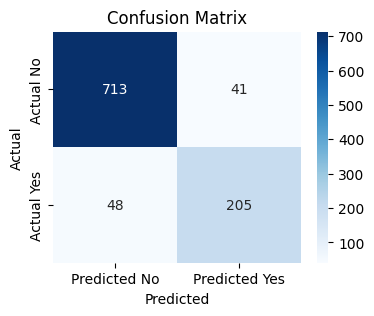

In [7]:
helper.singleModel(param, model_name="xgboost")
helper.printMetrics()
helper.showConfMatrix()

In [8]:
helper.shapConfig()

 96%|=================== | 962/1007 [00:11<00:00]       

In [9]:
features = helper.getTopFeatures(20)

Limiting SHAP values to range [-10, 10]


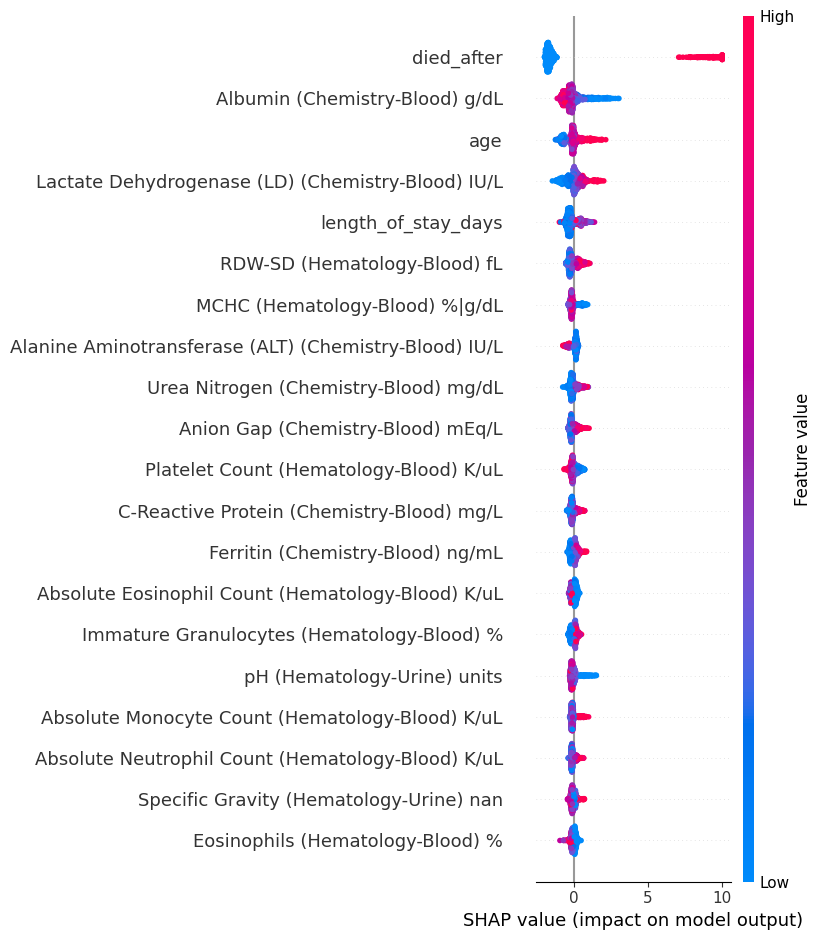

In [10]:
helper.showSummaryShap(verbose=2)

In [11]:
features

['died_after',
 'Albumin_Chemistry_Blood_g/dL',
 'age',
 'Lactate Dehydrogenase (LD)_Chemistry_Blood_IU/L',
 'length_of_stay_days',
 'RDW-SD_Hematology_Blood_fL',
 'MCHC_Hematology_Blood_%|g/dL',
 'Alanine Aminotransferase (ALT)_Chemistry_Blood_IU/L',
 'Urea Nitrogen_Chemistry_Blood_mg/dL',
 'Anion Gap_Chemistry_Blood_mEq/L',
 'Platelet Count_Hematology_Blood_K/uL',
 'C-Reactive Protein_Chemistry_Blood_mg/L',
 'Ferritin_Chemistry_Blood_ng/mL',
 'Absolute Eosinophil Count_Hematology_Blood_K/uL',
 'Immature Granulocytes_Hematology_Blood_%',
 'pH_Hematology_Urine_units',
 'Absolute Monocyte Count_Hematology_Blood_K/uL',
 'Absolute Neutrophil Count_Hematology_Blood_K/uL',
 'Specific Gravity_Hematology_Urine_nan',
 'Eosinophils_Hematology_Blood_%']

## Setup GMM

In [12]:
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [13]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

In [14]:
featuresNotConsidered = [x for x in data_covid.columns.tolist() if x not in features]

In [15]:
helper = cluster.GmmClusterHelper(data=data_covid, featuresNotConsidered=featuresNotConsidered)

In [16]:
asdas

NameError: name 'asdas' is not defined

## Find best hyperparameters for GMM

In [ ]:
param = {
    "n_components": {"min": 2, "max": 15},
    "covariance_type": ["full", "tied", "diag", "spherical"]
}

### DBCV

In [ ]:
os.environ["PYTHONWARNINGS"] = "ignore"
dbcv_df, dbcv_param, dbcv_best = helper.optunaGridSearch(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dbcv",
    suffix="death"
)

[I 2026-01-22 13:29:48,910] A new study created in RDB with name: Optuna Study GMM Death DBCV 0
[I 2026-01-22 13:29:52,846] Trial 0 finished with value: -0.9799051538387928 and parameters: {'n_components': 4, 'covariance_type': 'tied'}. Best is trial 0 with value: -0.9799051538387928.
[I 2026-01-22 13:29:56,598] Trial 1 finished with value: -0.8650757455149691 and parameters: {'n_components': 8, 'covariance_type': 'full'}. Best is trial 1 with value: -0.8650757455149691.
[I 2026-01-22 13:30:00,573] Trial 2 finished with value: -0.9337345329280814 and parameters: {'n_components': 6, 'covariance_type': 'full'}. Best is trial 1 with value: -0.8650757455149691.
[I 2026-01-22 13:30:03,923] Trial 3 finished with value: -0.8853090814129637 and parameters: {'n_components': 7, 'covariance_type': 'full'}. Best is trial 1 with value: -0.8650757455149691.
[I 2026-01-22 13:30:07,608] Trial 4 finished with value: -0.9799051538387928 and parameters: {'n_components': 4, 'covariance_type': 'tied'}. Bes


Best parameters: {'n_components': 14, 'covariance_type': 'full'}
Best DBCV score: -0.8105046861473983



### DISCO

In [ ]:
os.environ['PYTHONWARNINGS'] = 'ignore'
disco_df, disco_param, disco_best = helper.optunaGridSearch(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="disco",
    suffix="death"
)

[I 2026-01-22 13:33:50,432] A new study created in RDB with name: Optuna Study GMM Death DISCO 0
[I 2026-01-22 13:33:51,478] Trial 0 finished with value: -0.18576376278495704 and parameters: {'n_components': 12, 'covariance_type': 'full'}. Best is trial 0 with value: -0.18576376278495704.
[I 2026-01-22 13:33:52,346] Trial 1 finished with value: -0.2315992811880459 and parameters: {'n_components': 7, 'covariance_type': 'tied'}. Best is trial 0 with value: -0.18576376278495704.
[I 2026-01-22 13:33:53,016] Trial 2 finished with value: -0.16719882498553196 and parameters: {'n_components': 9, 'covariance_type': 'diag'}. Best is trial 2 with value: -0.16719882498553196.
[I 2026-01-22 13:33:53,688] Trial 3 finished with value: -0.15720024470332195 and parameters: {'n_components': 8, 'covariance_type': 'diag'}. Best is trial 3 with value: -0.15720024470332195.
[I 2026-01-22 13:33:54,371] Trial 4 finished with value: -0.18773524413127793 and parameters: {'n_components': 14, 'covariance_type': '


Best parameters: {'n_components': 2, 'covariance_type': 'full'}
Best DISCO score: 0.48016425156744225



### DSI

In [ ]:
os.environ['PYTHONWARNINGS'] = 'ignore'
dsi_df, dsi_param, dsi_best = helper.optunaGridSearch(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dsi",
    suffix="death"
)

[I 2026-01-22 13:34:45,567] A new study created in RDB with name: Optuna Study GMM Death DSI 0
[I 2026-01-22 13:34:46,709] Trial 0 finished with value: 0.128 and parameters: {'n_components': 6, 'covariance_type': 'diag'}. Best is trial 0 with value: 0.128.
[I 2026-01-22 13:34:48,152] Trial 1 finished with value: 0.147 and parameters: {'n_components': 11, 'covariance_type': 'diag'}. Best is trial 1 with value: 0.147.
[I 2026-01-22 13:34:49,624] Trial 2 finished with value: 0.107 and parameters: {'n_components': 8, 'covariance_type': 'spherical'}. Best is trial 1 with value: 0.147.
[I 2026-01-22 13:34:50,718] Trial 3 finished with value: 0.142 and parameters: {'n_components': 4, 'covariance_type': 'diag'}. Best is trial 1 with value: 0.147.
[I 2026-01-22 13:34:51,920] Trial 4 finished with value: 0.168 and parameters: {'n_components': 8, 'covariance_type': 'diag'}. Best is trial 4 with value: 0.168.
[I 2026-01-22 13:34:53,744] Trial 5 finished with value: 0.105 and parameters: {'n_compon


Best parameters: {'n_components': 2, 'covariance_type': 'diag'}
Best DSI score: 0.251



### Silhouette

In [ ]:
os.environ['PYTHONWARNINGS'] = 'ignore'
silhouette_df, silhouette_param, silhouette_best = helper.optunaGridSearch(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="silhouette",
    suffix="death"
)

[I 2026-01-22 13:36:12,137] A new study created in RDB with name: Optuna Study GMM Death SILHOUETTE 0
[I 2026-01-22 13:36:12,335] Trial 0 finished with value: -0.241 and parameters: {'n_components': 13, 'covariance_type': 'diag'}. Best is trial 0 with value: -0.241.
[I 2026-01-22 13:36:12,363] Trial 1 finished with value: -3.0 and parameters: {'n_components': 2, 'covariance_type': 'tied'}. Best is trial 0 with value: -0.241.
[I 2026-01-22 13:36:12,928] Trial 2 finished with value: -0.071 and parameters: {'n_components': 8, 'covariance_type': 'full'}. Best is trial 2 with value: -0.071.
[I 2026-01-22 13:36:13,578] Trial 3 finished with value: -0.233 and parameters: {'n_components': 15, 'covariance_type': 'full'}. Best is trial 2 with value: -0.071.
[I 2026-01-22 13:36:13,759] Trial 4 finished with value: -0.261 and parameters: {'n_components': 12, 'covariance_type': 'diag'}. Best is trial 2 with value: -0.071.
[I 2026-01-22 13:36:13,989] Trial 5 finished with value: -0.17 and parameters


Best parameters: {'n_components': 2, 'covariance_type': 'diag'}
Best SILHOUETTE score: 0.408



### Metrics

In [ ]:
helper.clustering(
    n_components=dbcv_param["n_components"],
    covariance_type=dbcv_param["covariance_type"],
)
helper.getMetrics()

{'silhouette': -0.175,
 'dbcv': -0.8105046861473983,
 'dsi': np.float64(0.173),
 'disco': np.float64(-0.16950991780403007)}

In [ ]:
helper.clustering(
    n_components=disco_param["n_components"],
    covariance_type=disco_param["covariance_type"],
)
helper.getMetrics()

{'silhouette': 0.396,
 'dbcv': -0.9702640945972513,
 'dsi': np.float64(0.239),
 'disco': np.float64(0.48016425156744225)}

In [ ]:
helper.clustering(
    n_components=dsi_param["n_components"],
    covariance_type=dsi_param["covariance_type"],
)
helper.getMetrics()

{'silhouette': 0.408,
 'dbcv': -0.9933987748863178,
 'dsi': np.float64(0.251),
 'disco': np.float64(0.47524231196472366)}

In [ ]:
helper.clustering(
    n_components=silhouette_param["n_components"],
    covariance_type=silhouette_param["covariance_type"],
)
helper.getMetrics()

{'silhouette': 0.408,
 'dbcv': -0.9933987748863178,
 'dsi': np.float64(0.251),
 'disco': np.float64(0.47524231196472366)}

In [ ]:
dasdasd

NameError: name 'dasdasd' is not defined

In [ ]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.getMetrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"GMM, None, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")

## GMM - Results

In [17]:
gmm_best_param = {'n_components': 2, 'covariance_type': 'full'}

/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:259: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_stats = self.__clusteredData.groupby("Cluster").apply(calculate_stats)
/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:1699: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.87 x' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_labels.loc[idx] = df.loc[idx].map(lambda x: f"{x:.2f} x")
/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:1699: FutureWarning: Setting an item of in

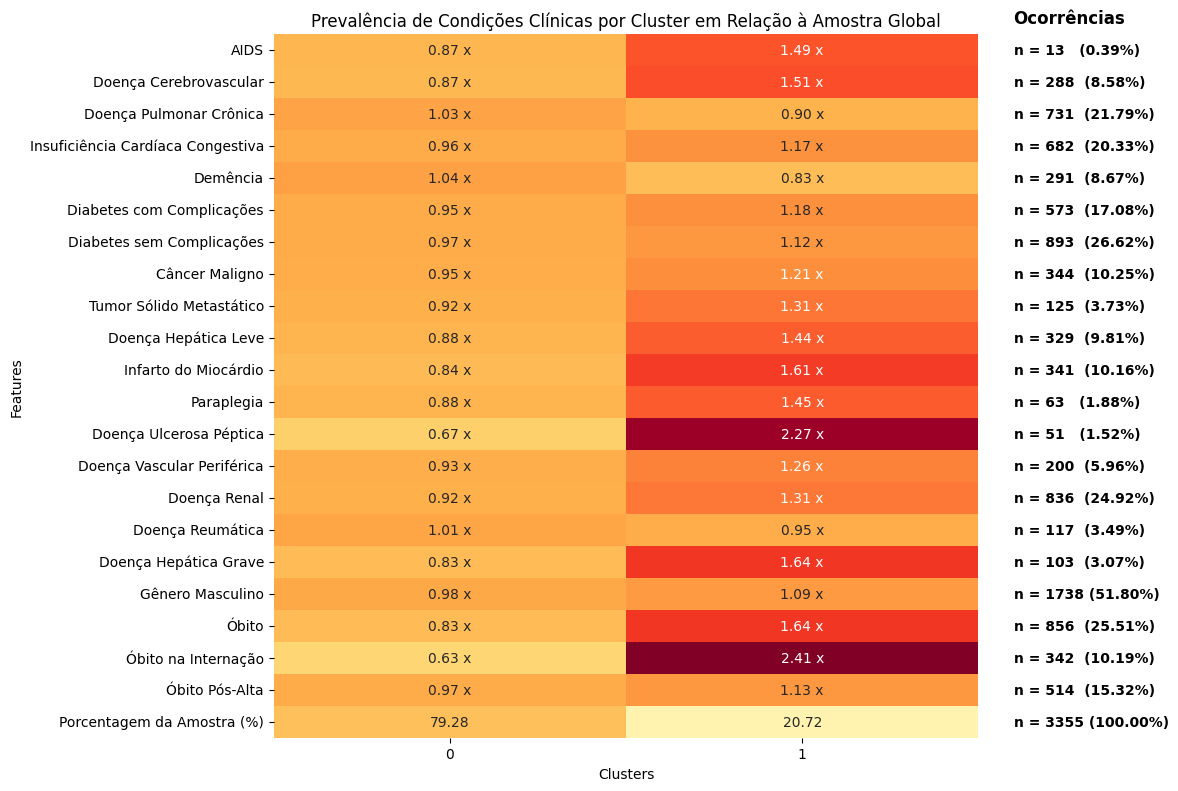

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.396,
 'dbcv': -0.9702640945972513,
 'dsi': np.float64(0.239),
 'disco': np.float64(0.48016425156744225)}

In [20]:
helper.clustering(
    n_components=gmm_best_param["n_components"],
    covariance_type=gmm_best_param["covariance_type"],
)
helper.heatmapClustersCategorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP, 
    relativeTotal=True,
    # savepath=IMAGES_SAVE_PATH + "gmm-death-categorical"
)
helper.getMetrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/v

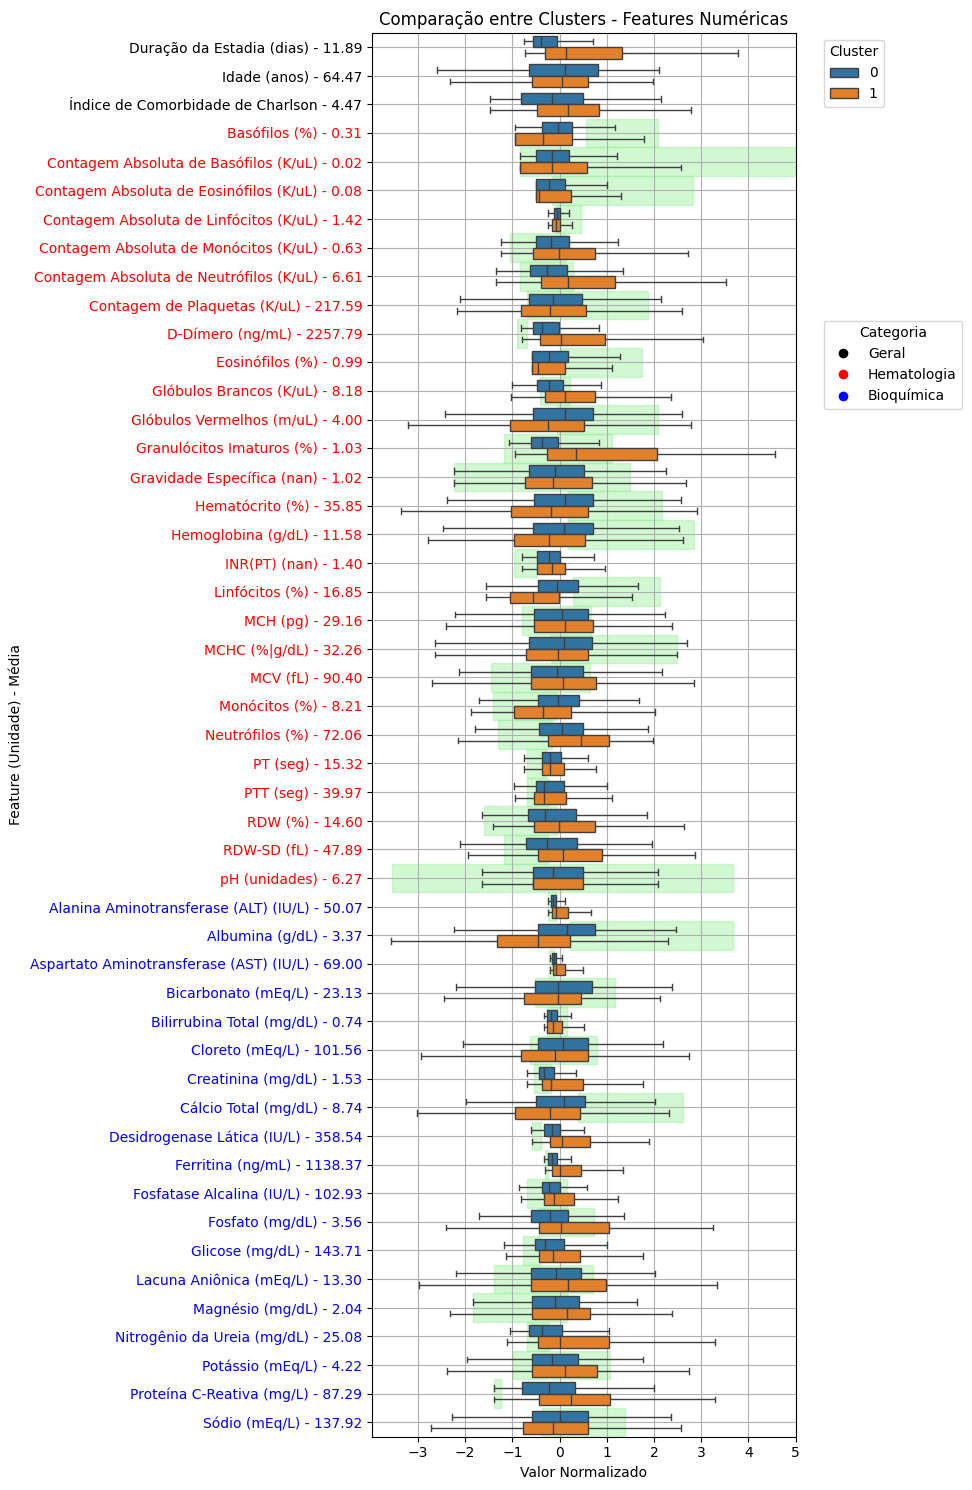

[('Immature Granulocytes_Hematology_Blood_%',
  np.float64(4.2120947225482475e-72)),
 ('length_of_stay_days', np.float64(5.706084614934552e-54)),
 ('Ferritin_Chemistry_Blood_ng/mL', np.float64(2.735222125673427e-50)),
 ('Lactate Dehydrogenase (LD)_Chemistry_Blood_IU/L',
  np.float64(3.375931990333978e-46)),
 ('Lymphocytes_Hematology_Blood_%', np.float64(5.683419975425888e-44)),
 ('Albumin_Chemistry_Blood_g/dL', np.float64(4.539822753714994e-40)),
 ('Absolute Neutrophil Count_Hematology_Blood_K/uL',
  np.float64(3.467959652086841e-37)),
 ('D-Dimer_Hematology_Blood_ng/mL|ng/mL FEU',
  np.float64(9.183445954172665e-37)),
 ('White Blood Cells_Hematology_Blood_K/uL',
  np.float64(2.5387182873929116e-35)),
 ('Asparate Aminotransferase (AST)_Chemistry_Blood_IU/L',
  np.float64(8.629719391027915e-34)),
 ('Urea Nitrogen_Chemistry_Blood_mg/dL', np.float64(6.034033211723368e-29)),
 ('Neutrophils_Hematology_Blood_%', np.float64(3.452715012950702e-27)),
 ('Alanine Aminotransferase (ALT)_Chemistry_B

In [19]:
helper.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=-1,
    figsize=(10, 15),
    # savepath=IMAGES_SAVE_PATH + "gmm-death-numerical"
)

In [21]:
selectedClusters = [0,1]

In [22]:
helper.setClusteredAutoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:24<00:00,  4.05it/s]


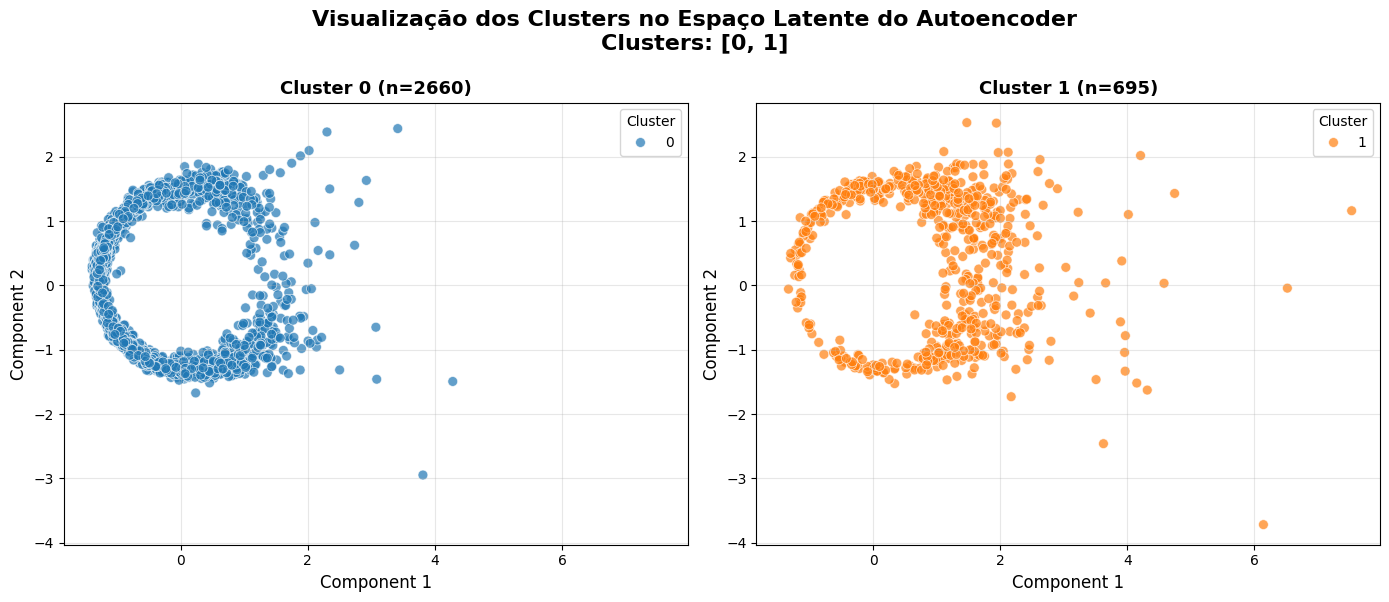

In [23]:
helper.showClusteredAutoencoder(
    selectedClusters=selectedClusters,
    # savepath=IMAGES_SAVE_PATH + "gmm-autoencoder-death",
)

### Future Data

2026-01-30 14:07:16,813 - Modules.FutureAnalysisModule - WARNING - 84 subject_ids in target data are missing from reference data. These will be filtered out.
2026-01-30 14:07:16,823 - Modules.FutureAnalysisModule - WARNING - 551 subject_ids in target data are missing from reference data. These will be filtered out.
2026-01-30 14:07:16,842 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 3649 records
2026-01-30 14:07:16,857 - Modules.FutureAnalysisModule - INFO - Auto-detected 19 binary features for analysis
2026-01-30 14:07:16,882 - Modules.FutureAnalysisModule - INFO - Delta clusters calculated for 1 clusters
2026-01-30 14:07:16,884 - Modules.FutureAnalysisModule - INFO - FutureAnalysisHelper initialized with 3355 past records and 2257 future records
2026-01-30 14:07:16,889 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-01-30 14:07:16,893 - Modules.FutureAnalysisModule - INFO - Auto-detected 20 binary features for analysis
2026-01-30 14:07:

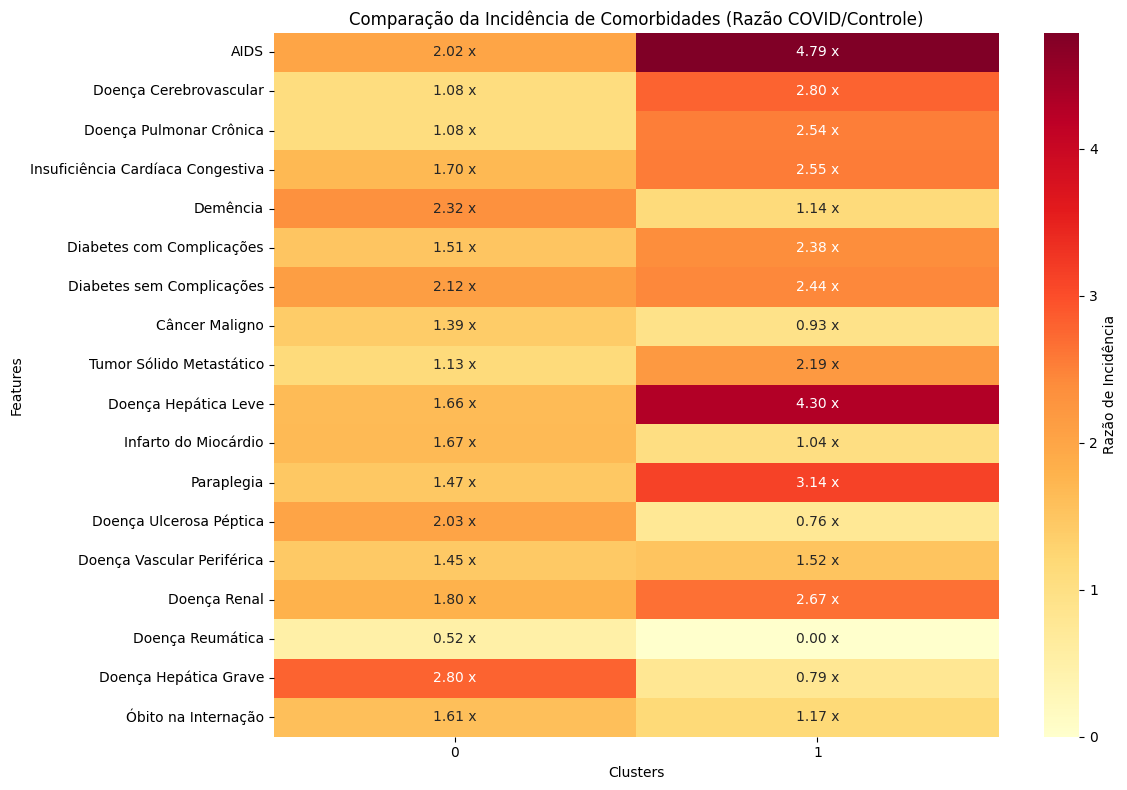

In [24]:
future_helper = fa.FutureAnalysisHelper(
    helper.clusteredData, future_data, control, control_readmission
)
delta = future_helper.get_delta_clusters(percentage=True, relative_total=True)
future_helper.show_delta_heatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    relative_total=True,
    selected_clusters=selectedClusters,
    # savepath=IMAGES_SAVE_PATH + "gmm-death-future",
)

In [ ]:
future_helper.getMeanReadmission()

In [ ]:
future_helper.getMeanDaysGap()

In [ ]:
future_helper.getMortalityRates(onlyFirstAdmission=True)

# Add Log

In [ ]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.getMetrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"GMM, Shap, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")